In [22]:
import pandas as pd
from well_structured.modules.compare_results import compute_auc_comparison_figures, compute_dbscan_test_comparison_figures
from well_structured.modules.utils.clustering_utils import test_dbscan_bamboo, test_dbscan_pf, test_dbscan_pintor, test_groupby_on_combinations
from well_structured.modules.utils.clustering_utils import cluster_oneshot_groupby, cluster_oneshot_dbscan, compute_clustering_metrics, compute_clustering_metrics_advanced
import ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
RANDOM_STATE = 42


In [23]:
def apply_one_shot_clustering(X, y, eps, n_samples, method="bamboo"):
    X_groupby = X.copy()
    X_dbscan = X.copy()
    
    X_groupby = cluster_oneshot_groupby(X_groupby)
    X_groupby["true_label"] = y
    
    # Convert list fingerprints into a dense 2D matrix for DBSCAN
    if method == "bamboo":
        X_dbscan_np = np.asarray(X_dbscan["bamboo_fprint"].tolist(), dtype=float)
    elif method == "pf":
        X_dbscan_np = X_dbscan.to_numpy().reshape(-1, 1)
    else:
        X_dbscan_np = np.asarray(X_dbscan.to_numpy())
    clusters = cluster_oneshot_dbscan(X_dbscan_np, eps=eps, min_samples=n_samples, metric="hamming")
    X_dbscan["true_label"] = y
    X_dbscan["cluster"] = clusters.tolist()
    
    groupby_metrics = compute_clustering_metrics_advanced(
        y_true=y,
        cluster_labels=X_groupby["cluster"].to_numpy(),
    )
    
    dbscan_metrics = compute_clustering_metrics_advanced(
        y_true=y,
        cluster_labels=X_dbscan["cluster"].to_numpy(),
    )
    
    metrics_df = pd.DataFrame([
        {"method": "groupby", **groupby_metrics},
        {"method": "dbscan", **dbscan_metrics},
    ]).sort_values(by="v_measure_clustered", ascending=False).reset_index(drop=True)
    
    return X_groupby, X_dbscan, metrics_df

def plot_clusters(X, n_bits, title="DBSCAN Clusters", method="bamboo", ax=None):
    # Plot DBSCAN clusters by projecting each 32-bit fingerprint into two 16-bit integers.
    # Fingerprints are encoded as -1/1, so we convert to 0/1 bits first.
    X_plot = X.copy()
    # Keep exactly 32 values, then map -1 -> 0 and 1 -> 1.
    if method == "bamboo":
        X_plot[f"bits_{n_bits}"] = X_plot["bamboo_fprint"].apply(
            lambda f: (np.asarray(f[:n_bits], dtype=float) > 0).astype(int)
        )
        # Split into first 16 bits and second 16 bits, then convert each half to an integer.
        X_plot["bamboo_fprint_x"] = X_plot[f"bits_{n_bits}"].apply(
            lambda b: int("".join(map(str, b[:n_bits//2].tolist())), 2)
        )
        X_plot["bamboo_fprint_y"] = X_plot[f"bits_{n_bits}"].apply(
            lambda b: int("".join(map(str, b[n_bits//2:n_bits].tolist())), 2)
        )
        xlabel = f"BAMBOO Fingerprint first {n_bits//2} bits (as int)"
        ylabel = f"BAMBOO Fingerprint second {n_bits//2} bits (as int)"
    elif method == "pf":
        # pf_fprint_{n_bits} is already a integer with 32 bits, so we can directly split it into two 16-bit integers.
        X_plot["bamboo_fprint_x"] = X_plot[f"pf_fprint_{n_bits}"].apply(
            lambda f: (f >> (n_bits//2)) & ((1 << (n_bits//2)) - 1)
        )
        X_plot["bamboo_fprint_y"] = X_plot[f"pf_fprint_{n_bits}"].apply(
            lambda f: f & ((1 << (n_bits//2)) - 1)
        )
        xlabel = f"PF Fingerprint first {n_bits//2} bits (as int)"
        ylabel = f"PF Fingerprint second {n_bits//2} bits (as int)"
        
    elif method == "pintor":
        # For pintor, we can directly use the two columns as x and y.
        X_plot["bamboo_fprint_x"] = X_plot.iloc[:, 0].astype(float)
        X_plot["bamboo_fprint_y"] = X_plot.iloc[:, 1].astype(float)
        xlabel = f"Pintor Column 1"
        ylabel = f"Pintor Column 2"
        
        
    # Convert string true labels to deterministic integer ids (sorted by label string).
    X_plot["true_label_str"] = X_plot["true_label"].astype(str)
    X_plot["true_label_id"], label_names = pd.factorize(X_plot["true_label_str"], sort=True)

    # Add light jitter for visibility when many points overlap.
    rng = np.random.default_rng(RANDOM_STATE)
    jitter_perc = 0.01 # in percentage of the range of x and y values
    jitter = jitter_perc * max(X_plot["bamboo_fprint_x"].max() - X_plot["bamboo_fprint_x"].min(), X_plot["bamboo_fprint_y"].max() - X_plot["bamboo_fprint_y"].min())
    
    X_plot["bamboo_fprint_x_j"] = X_plot["bamboo_fprint_x"] + rng.uniform(-jitter, jitter, size=len(X_plot))
    X_plot["bamboo_fprint_y_j"] = X_plot["bamboo_fprint_y"] + rng.uniform(-jitter, jitter, size=len(X_plot))

    # Fill color by predicted cluster.
    cluster_ids = sorted(X_plot["cluster"].astype(int).unique().tolist())
    cluster_cmap = plt.get_cmap("tab10", max(len(cluster_ids), 1))
    cluster_to_color = {cid: cluster_cmap(i) for i, cid in enumerate(cluster_ids)}

    # Edge color by integer true-label id.
    true_label_ids = sorted(X_plot["true_label_id"].astype(int).unique().tolist())
    label_cmap = plt.get_cmap("Set1", max(len(true_label_ids), 1))
    labelid_to_edgecolor = {lid: label_cmap(i) for i, lid in enumerate(true_label_ids)}

    if ax is None:
        plt.figure(figsize=(4, 4))
        ax = plt.gca()
        
    for cid in cluster_ids:
        m = X_plot["cluster"].astype(int) == cid
        dev_id_color = X_plot.loc[m, "true_label_id"].astype(int).map(labelid_to_edgecolor).tolist()
        ax.scatter(
            X_plot.loc[m, "bamboo_fprint_x_j"],
            X_plot.loc[m, "bamboo_fprint_y_j"],
            color=dev_id_color,
            edgecolors=cluster_to_color[cid],
            linewidths=1.2,
            s=70,
            alpha=0.78,
        )

    cluster_handles = [
        Line2D([0], [0], marker="o", linestyle="", markerfacecolor="white", markeredgecolor=cluster_to_color[cid], label=f"cluster {cid}", markersize=8)
        for cid in cluster_ids
    ]
    label_handles = [
        Line2D(
            [0], [0], marker="o", linestyle="", markerfacecolor=labelid_to_edgecolor[lid],
            markeredgecolor=labelid_to_edgecolor[lid], markeredgewidth=1,
            label=f"Device id {lid} ({label_names[lid]})", markersize=8
        )
        for lid in true_label_ids
    ]

    legend_clusters = ax.legend(handles=cluster_handles, title="Predicted Clusters", loc=5)
    ax.add_artist(legend_clusters)
    ax.legend(handles=label_handles, title="True Labels (edge)")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)


In [24]:
comb_len = 5
n_bits = 16
cycle = 0
out_dir = f"C:/Users/fabio/Ricerca/Codice/2026_Bamboo_Journal/well_structured/results/cycle_{cycle}/"

# read test combinations
test_combinations_df = pd.read_csv(out_dir + f"test_combinations.csv")
test_combinations_df["combination"] = test_combinations_df["combination"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
single_comb = test_combinations_df.loc[test_combinations_df["length"] == comb_len, "combination"].iloc[0]


In [25]:
method = "bamboo"
best_res_df = pd.read_csv(out_dir + f"{method}/best_dbscan_params_{n_bits}_bits.csv")
best_eps = best_res_df.loc[0, "eps"]
best_min_samples = best_res_df.loc[0, "min_samples"]

# read bamboo test df with fingerprints
bamboo_test_df = pd.read_csv(out_dir + f"bamboo/bamboo_test_df_with_fprints.csv")
bamboo_test_df["bamboo_fprint"] = bamboo_test_df["bamboo_fprint"].apply(lambda x: eval(x) if isinstance(x, str) else x)

### BAMBOO TESTING ###
# prepare X and y for bamboo test data
X = bamboo_test_df[["bamboo_fprint"]].copy()
X["bamboo_fprint"] = X["bamboo_fprint"].apply(lambda f: f[:n_bits])
y = bamboo_test_df["label"].values

# test on a single combination
#single_comb = test_combinations_df["combination"].iloc[0]
single_comb = test_combinations_df.loc[test_combinations_df["length"] == comb_len, "combination"].iloc[0]
print(f"Testing single combination {single_comb} with groupby...")
mask = np.isin(y, single_comb)
X_subset = X[mask]
y_subset = y[mask]


X_groupby, X_dbscan, metrics_df = apply_one_shot_clustering(X_subset, y_subset, eps=best_eps, n_samples=best_min_samples)

print("Clustering metrics for single combination:")
metrics_df

Testing single combination ('SamsungA50_DM_AR', 'iPhone15Pro_AS_AR', 'HuaweiMediapadT5_GV_AR', 'SamsungJ6_K', 'iPhone6_N') with groupby...
Clustering metrics for single combination:


,method,noise_ratio,coverage,n_clusters,homogeneity_all,completeness_all,v_measure_all,ari_all,nmi_all,homogeneity_clustered,completeness_clustered,v_measure_clustered,ari_clustered,nmi_clustered,label_accuracy
0,dbscan,0.0004,0.9996,15,0.857138,0.785823,0.819933,0.803512,0.819933,0.857081,0.787039,0.820568,0.803920,0.820568,0.9264
1,groupby,0.0000,1.0000,16,0.857138,0.785823,0.819933,0.803512,0.819933,0.857138,0.785823,0.819933,0.803512,0.819933,0.9268


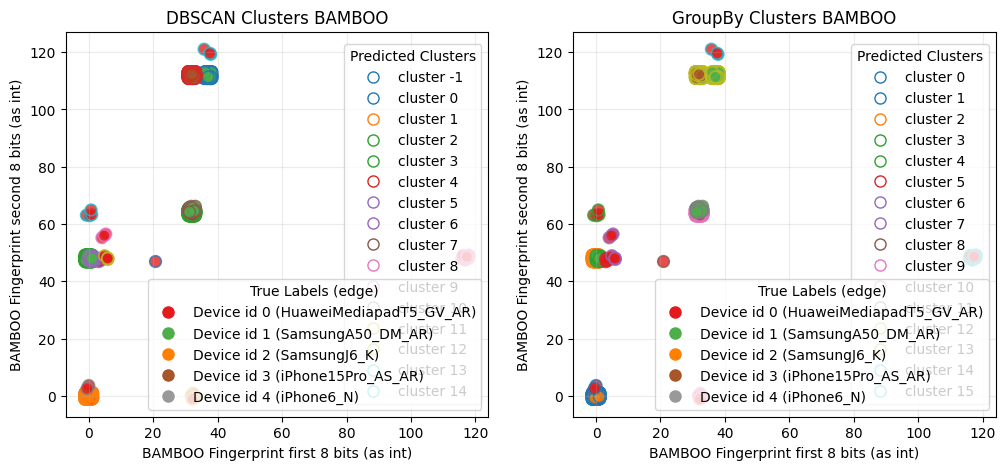

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_clusters(X_dbscan, n_bits=n_bits, title=f"DBSCAN Clusters BAMBOO", method="bamboo", ax=axes[0])
plot_clusters(X_groupby, n_bits=n_bits, title=f"GroupBy Clusters BAMBOO", method="bamboo", ax=axes[1])
plt.show()

### PF

In [27]:
method = "pf"
best_res_df = pd.read_csv(out_dir + f"{method}/best_dbscan_params_{n_bits}_bits.csv")
best_eps = best_res_df.loc[0, "eps"]
best_min_samples = best_res_df.loc[0, "min_samples"]

# read pf test df with fingerprints
pf_test_df = pd.read_csv(out_dir + "pf/pf_test_df_with_fprints.csv")


X = pf_test_df[[f"pf_fprint_{n_bits}"]].copy()
y = pf_test_df["label"].values

# test on a single combination
#single_comb = test_combinations_df["combination"].iloc[0]
single_comb = test_combinations_df.loc[test_combinations_df["length"] == comb_len, "combination"].iloc[0]
print(f"Testing single combination {single_comb} with groupby...")
mask = np.isin(y, single_comb)
X_subset = X[mask]
y_subset = y[mask]

X_groupby, X_dbscan, metrics_df = apply_one_shot_clustering(X_subset, y_subset, eps=best_eps, n_samples=best_min_samples, method="pf")

print("Clustering metrics for single combination:")
metrics_df




Testing single combination ('SamsungA50_DM_AR', 'iPhone15Pro_AS_AR', 'HuaweiMediapadT5_GV_AR', 'SamsungJ6_K', 'iPhone6_N') with groupby...
Clustering metrics for single combination:


,method,noise_ratio,coverage,n_clusters,homogeneity_all,completeness_all,v_measure_all,ari_all,nmi_all,homogeneity_clustered,completeness_clustered,v_measure_clustered,ari_clustered,nmi_clustered,label_accuracy
0,dbscan,0.0212,0.9788,17,0.962769,0.731735,0.831502,0.803780,0.831502,0.961940,0.751622,0.843874,0.824636,0.843874,0.9624
1,groupby,0.0000,1.0000,42,0.962769,0.709989,0.817279,0.802154,0.817279,0.962769,0.709989,0.817279,0.802154,0.817279,0.9836


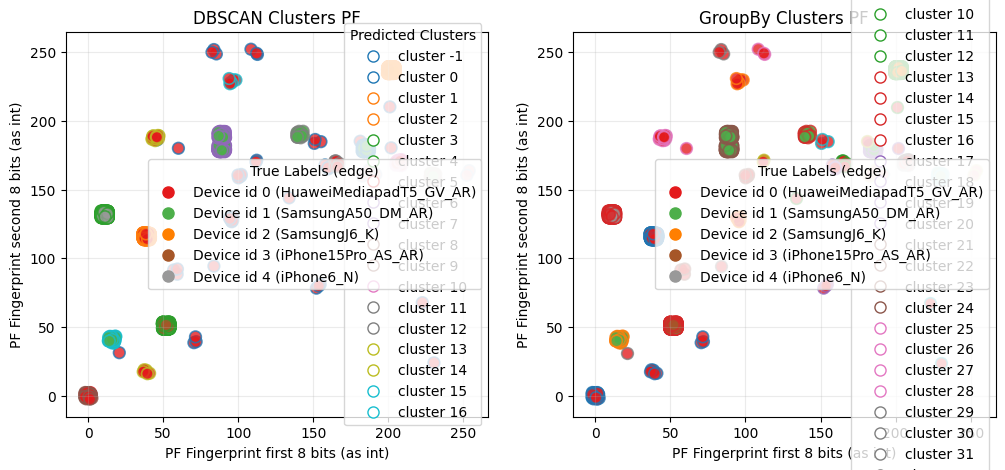

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_clusters(X_dbscan, n_bits=n_bits, title=f"DBSCAN Clusters PF", method="pf", ax=axes[0])
plot_clusters(X_groupby, n_bits=n_bits, title=f"GroupBy Clusters PF", method="pf", ax=axes[1])

### PINTOR

In [29]:
method = "pintor"
best_res_df = pd.read_csv(out_dir + f"{method}/best_dbscan_params_2_cols.csv")
best_eps = best_res_df.loc[0, "eps"]
best_min_samples = best_res_df.loc[0, "min_samples"]

# read pintor data
pintor_test_df = pd.read_csv(out_dir + "pintor/pintor_test_df_prepared.csv")
selected_columns = ["Extended Capabilities", "Vendor Specific Tags"]
X = pintor_test_df[selected_columns].copy()
y = pintor_test_df["Label"].values

# test on a single combination
mask = np.isin(y, single_comb)
X_subset = X[mask]
y_subset = y[mask]
# apply clustering with the two methods
X_groupby, X_dbscan, metrics_df = apply_one_shot_clustering(X_subset, y_subset, eps=best_eps, n_samples=best_min_samples, method="pintor")

print("Clustering metrics for single combination:")
metrics_df

Clustering metrics for single combination:


,method,noise_ratio,coverage,n_clusters,homogeneity_all,completeness_all,v_measure_all,ari_all,nmi_all,homogeneity_clustered,completeness_clustered,v_measure_clustered,ari_clustered,nmi_clustered,label_accuracy
0,dbscan,0.0164,0.9836,12,0.980551,0.799987,0.881114,0.876744,0.881114,0.980219,0.821157,0.893665,0.894640,0.893665,0.9716
1,groupby,0.0000,1.0000,33,0.980551,0.781065,0.869513,0.875833,0.869513,0.980551,0.781065,0.869513,0.875833,0.869513,0.9880


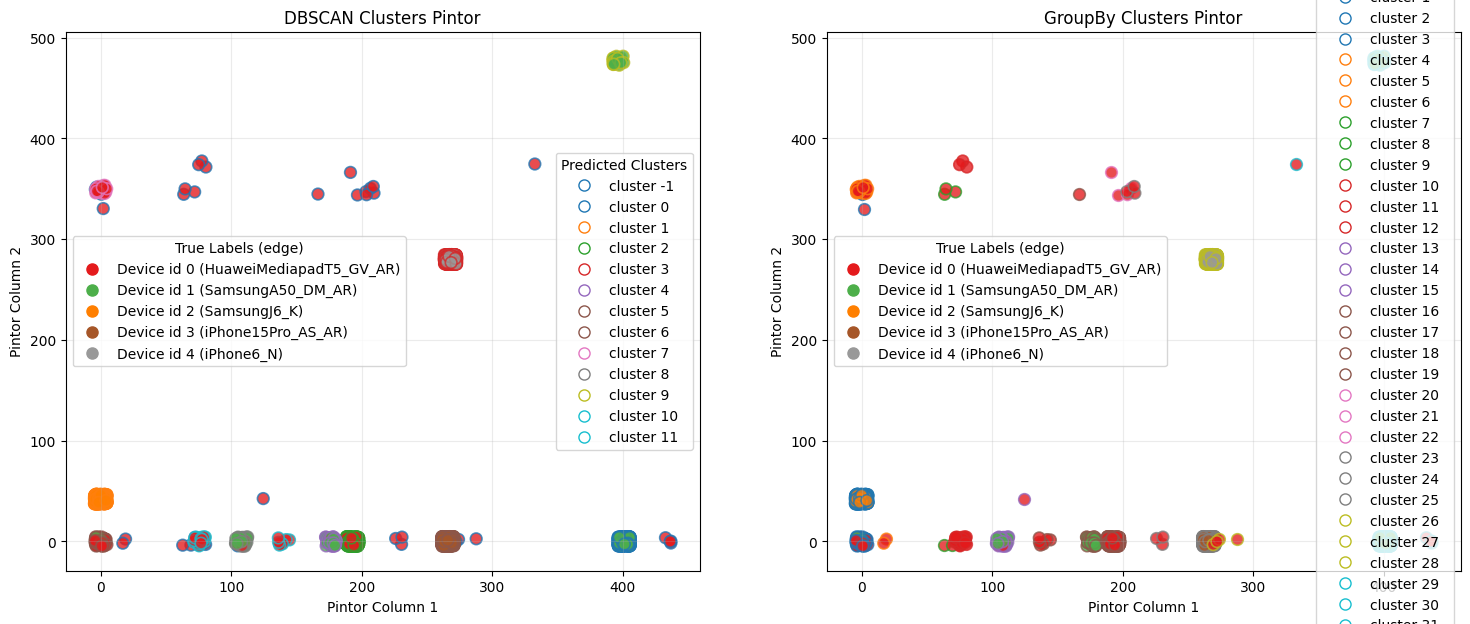

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_clusters(X_dbscan, n_bits=n_bits, title=f"DBSCAN Clusters Pintor", method="pintor", ax=axes[0])
plot_clusters(X_groupby, n_bits=n_bits, title=f"GroupBy Clusters Pintor", method="pintor", ax=axes[1])
plt.show()